In [ ]:
!wget https://github.com/DeepQuestAI/Fire-Smoke-Dataset/releases/download/v1/FIRE-SMOKE-DATASET.zip
!unzip FIRE-SMOKE-DATASET.zip

--2026-01-11 10:23:57--  https://github.com/DeepQuestAI/Fire-Smoke-Dataset/releases/download/v1/FIRE-SMOKE-DATASET.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/193940929/09220a00-9842-11e9-8756-2d8df8631bb5?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-01-11T11%3A02%3A56Z&rscd=attachment%3B+filename%3DFIRE-SMOKE-DATASET.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-01-11T10%3A02%3A39Z&ske=2026-01-11T11%3A02%3A56Z&sks=b&skv=2018-11-09&sig=OpG5x0EmHjp6%2FeirpWpJlG%2Fq90EgGIb2xBK7uPTvPz8%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2ODEzMDYzNywibmJmIjoxNzY4MTI3MDM3LCJwYXRoIjoicmVsZWFzZ

In [ ]:
import shutil
shutil.rmtree('/content/FIRE-SMOKE-DATASET/Test/Smoke')
shutil.rmtree('/content/FIRE-SMOKE-DATASET/Train/Smoke')

In [ ]:
!pip install keras_preprocessing
import tensorflow as tf
import keras_preprocessing
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator
import shutil
TRAINING_DIR = "/content/FIRE-SMOKE-DATASET/Train"

training_datagen = ImageDataGenerator(rescale=1./255,
																			zoom_range=0.15,
																			horizontal_flip=True,
                                      fill_mode='nearest')

VALIDATION_DIR = "/content/FIRE-SMOKE-DATASET/Test"
validation_datagen = ImageDataGenerator(rescale = 1./255)

train_generator = training_datagen.flow_from_directory(
	TRAINING_DIR,
	target_size=(224,224),
	shuffle = True,
	class_mode='categorical',
  batch_size = 128
)

validation_generator = validation_datagen.flow_from_directory(
	VALIDATION_DIR,
	target_size=(224,224),
	class_mode='categorical',
	shuffle = True,
  batch_size= 14
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.4 MB/s eta 0:00:00
Found 1800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Dropout

input_tensor = Input(shape=(224, 224, 3))

base_model = InceptionV3(input_tensor=input_tensor, weights='imagenet', include_top=False)

# add a global spatial average pooling layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(2048, activation='relu')(x)
x = Dropout(0.25)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['acc'])

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('val_loss')<=0.1099 and logs.get('loss')<=0.1099):
      print('\n\n Reached The Destination!')
      self.model.stop_training = True
callbacks = myCallback()

history = model.fit(
    train_generator,
    steps_per_epoch = 14,
    epochs = 20,
    validation_data = validation_generator,
    validation_steps = 14,
    callbacks=[callbacks]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 248s 17s/step - acc: 0.6254 - loss: 11.2753 - val_acc: 0.8878 - val_loss: 0.3737
Epoch 2/20
 1/14 ━━━━━━━━━━━━━━━━━━━━ 3:15 15s/step - acc: 0.9062 - loss: 0.2885

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


14/14 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - acc: 0.9062 - loss: 0.2885 - val_acc: 0.9541 - val_loss: 0.1216
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 262s 19s/step - acc: 0.9728 - loss: 0.0761 - val_acc: 0.9643 - val_loss: 0.1262
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - acc: 0.9609 - loss: 0.1048 - val_acc: 0.9541 - val_loss: 0.1414
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 261s 17s/step - acc: 0.9502 - loss: 0.3690 - val_acc: 0.9541 - val_loss: 0.1390
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - acc: 0.9922 - loss: 0.0642 - val_acc: 0.9592 - val_loss: 0.1117
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 262s 19s/step - acc: 0.9256 - loss: 0.2213 - val_acc: 0.9592 - val_loss: 0.1126
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - acc: 0.9609 - loss: 0.0859 - val_acc: 0.9592 - val_loss: 0.1197
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 253s 16s/step - acc: 0.9707 - loss: 0.0686 - val_acc: 0.9592 - val_loss: 0.1248
Epoch 10/20
 1/14 ━━━━━━━━━━━━━━━━━━━━ 4:48 22s/step - acc: 0.9688 - loss: 

In [ ]:
!pip install tensorflow
for layer in model.layers[:249]:
   layer.trainable = False
for layer in model.layers[249:]:
   layer.trainable = True

from tensorflow.keras.optimizers import SGD
model.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9), loss='categorical_crossentropy', metrics=['acc'])


class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('val_loss')<=0.1099 and logs.get('loss')<=0.1099):
      print('\n\n Reached The Destination!')
      self.model.stop_training = True
callbacks = myCallback()

history = model.fit(
    train_generator,
    steps_per_epoch = 14,
    epochs = 10,
    validation_data = validation_generator,
    validation_steps = 14,
    callbacks=[callbacks]
)
print(len(base_model.layers))

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 310s 21s/step - acc: 0.7634 - loss: 0.3997 - val_acc: 0.9643 - val_loss: 0.0992
Epoch 2/10
 1/14 ━━━━━━━━━━━━━━━━━━━━ 3:52 18s/step - acc: 0.8672 - loss: 0.3036

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


14/14 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - acc: 0.8672 - loss: 0.3036 - val_acc: 0.9643 - val_loss: 0.1009
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 321s 23s/step - acc: 0.8107 - loss: 0.3648 - val_acc: 0.9592 - val_loss: 0.1118
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - acc: 0.8047 - loss: 0.3506 - val_acc: 0.9592 - val_loss: 0.1141
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 290s 21s/step - acc: 0.8540 - loss: 0.3060 - val_acc: 0.9592 - val_loss: 0.1176
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - acc: 0.9141 - loss: 0.2281 - val_acc: 0.9541 - val_loss: 0.1246
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 323s 23s/step - acc: 0.8786 - loss: 0.2837 - val_acc: 0.9592 - val_loss: 0.1316
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - acc: 0.8750 - loss: 0.2736 - val_acc: 0.9592 - val_loss: 0.1388
Epoch 9/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 289s 20s/step - acc: 0.8914 - loss: 0.2635 - val_acc: 0.9490 - val_loss: 0.1483
Epoch 10/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - acc: 0.9219 - loss: 0.

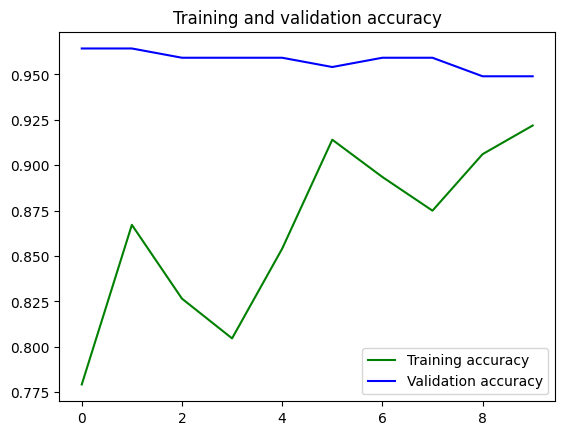

<Figure size 640x480 with 0 Axes>

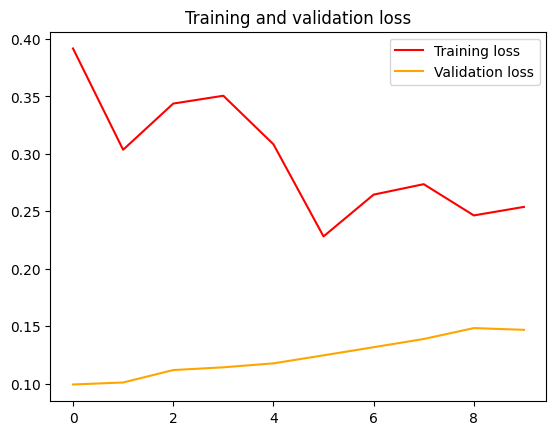

<Figure size 640x480 with 0 Axes>

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'g', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')

plt.legend(loc=0)
plt.figure()
plt.show()

plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'orange', label='Validation loss')
plt.title('Training and validation loss')

plt.legend(loc=0)
plt.figure()
plt.show()

In [ ]:
# Save your model as an H5 file
model.save('my_model.h5')


In [ ]:
# Save in native Keras format
model.save("my_model.keras")



In [ ]:
from google.colab import files

# Download the Keras model
files.download("my_model.keras")




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('my_model.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
from google.colab import files
from keras.preprocessing import image

uploaded = files.upload()
for fn in uploaded.keys():
  path = '/content/' + fn
  img = image.load_img(path, target_size=(224, 224))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0) /255
  classes = model.predict(x)
  print(np.argmax(classes[0])==0, max(classes[0]))

Saving 4-1.JPG to 4-1.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
False 0.84873474
